# 03 -- Merge, Look-Ahead Bias & Backtest

Tohle je klicovy notebook celeho projektu. Delame v nem 4 veci, v tomto
poradi, protoze kazda dalsi stavi na te predchozi:

1. **Spojeni dat** cenove + sentiment na jednu casovou osu, s peclivym
   osetrenim vikendu/svatku (Reddit bezi 7 dni v tydnu, trh jen 5)
2. **Definice signalu** -- co presne znamena "nahly vykyv sentimentu"
   (z-score, ne surova hodnota)
3. **Backtest** jednoduche strategie proti benchmarku (buy-and-hold),
   vcetne transakcnich nakladu
4. **Statisticke vyhodnoceni** -- je vysledek nahoda, nebo ne?
   (permutacni test, out-of-sample split)

**Klicovy princip cele teto casti:** signal zjisteny k datu T smi
ovlivnit jen obchod provedeny PO datu T (realisticky az T+1). Nikdy
neuzivame informaci, ktera by v realnem case jeste nebyla znama.

## Import knihoven

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

np.random.seed(42)  # pro reprodukovatelnost permutacniho testu nize

In [2]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

prices = pd.read_csv(PROCESSED_DIR / "prices_clean.csv", parse_dates=["Date"])
sentiment = pd.read_csv(PROCESSED_DIR / "reddit_daily_sentiment.csv", parse_dates=["Date"])

print(f"Prices:    {len(prices)} radku, tickery: {sorted(prices['Ticker'].unique())}")
print(f"Sentiment: {len(sentiment)} radku, tickery: {sorted(sentiment['Ticker'].unique())}")

Prices:    14635 radku, tickery: ['AAPL', 'AMC', 'AMZN', 'DIS', 'GME', 'MSFT', 'NVDA', 'PLTR', 'TSLA']
Sentiment: 2591 radku, tickery: ['AAPL', 'AMC', 'AMZN', 'DIS', 'GME', 'MSFT', 'NVDA', 'PLTR', 'TSLA']


## 1. Spojeni dat s osetrenim vikendu/svatku

Reddit generuje posty kazdy den, ale burza obchoduje jen ve vsedni dny.
Pokud nekdo napise "GME to the moon" v sobotu, tenhle sentiment je
znamy az pondelnimu obchodovani -- **musime ho tedy priradit k
nejblizsimu nasledujicimu obchodnimu dni**, ne ho zahodit ani ho
nechat viset na dni, kdy se neobchodovalo.

Pouzijeme `pd.merge_asof` se smerem `forward` -- pro kazdy Reddit den
najde nejblizsi obchodni den, ktery nastava ve stejny den nebo pozdeji.

In [3]:
# Kalendar obchodnich dnu -- sjednoceni napric vsemi tickery (nektere,
# jako PLTR, maji kratsi historii, ale kalendar samotny je spolecny)
trading_days = pd.Series(sorted(prices["Date"].unique()), name="Date")
print(f"Pocet obchodnich dnu v datasetu: {len(trading_days)}")

Pocet obchodnich dnu v datasetu: 1647


In [4]:
rolled = []
for ticker, group in sentiment.groupby("Ticker"):
    g = group.rename(columns={"Date": "Date_original"})
    g = g.sort_values("Date_original")
    calendar = pd.DataFrame({"Date": trading_days}).sort_values("Date")
    mapped = pd.merge_asof(
        g, calendar, left_on="Date_original", right_on="Date", direction="forward"
    )
    mapped["Ticker"] = ticker
    rolled.append(mapped)

sentiment_rolled = pd.concat(rolled, ignore_index=True)

# Radky, kde se nenasel zadny nasledujici obchodni den (posty uplne na
# konci datasetu, po poslednim obchodnim dni) zahodime -- nemame k nim
# stejne zadnou cenu, se kterou by se daly spojit
n_before = len(sentiment_rolled)
sentiment_rolled = sentiment_rolled.dropna(subset=["Date"])
print(f"Zahozeno {n_before - len(sentiment_rolled)} radku bez nasledujiciho obchodniho dne")

Zahozeno 0 radku bez nasledujiciho obchodniho dne


### Agregace po prirazeni k obchodnimu dni

Nekolik puvodnich (vikendovych) dnu se ted muze mapovat na stejny
obchodni den (napr. patek + sobota + nedele -> pondeli). Musime je
agregovat -- pocty postu scitame, prumerny sentiment vazime poctem
postu (den s 50 posty by mel vic vahy nez den se 2 posty).

In [5]:
def weighted_mean(values, weights):
    if weights.sum() == 0:
        return 0.0
    return np.average(values, weights=weights)

sentiment_daily = (
    sentiment_rolled
    .groupby(["Ticker", "Date"])
    .apply(lambda g: pd.Series({
        "post_count": g["post_count"].sum(),
        "avg_sentiment": weighted_mean(g["avg_sentiment"], g["post_count"]),
        "positive_count": g["positive_count"].sum(),
        "negative_count": g["negative_count"].sum(),
    }), include_groups=False)
    .reset_index()
)

print(f"Po agregaci: {len(sentiment_daily)} radku (ticker, obchodni den)")
sentiment_daily.head()

Po agregaci: 1946 radku (ticker, obchodni den)


,Ticker,Date,post_count,avg_sentiment,positive_count,negative_count
0,AAPL,2020-01-02,7.0,0.329305,3.0,0.0
1,AAPL,2020-01-03,6.0,0.278295,2.0,0.0
2,AAPL,2020-01-06,5.0,-0.159124,1.0,2.0
3,AAPL,2020-01-08,4.0,-0.066181,1.0,1.0
4,AAPL,2020-01-09,16.0,0.532786,10.0,0.0


## 2. Spojeni s cenami

Levy join na cenova data -- chceme zachovat vsechny obchodni dny, i ty
bez zadne Reddit aktivity (tam bude `post_count = 0`).

In [6]:
df = prices.merge(sentiment_daily, on=["Ticker", "Date"], how="left")

df["post_count"] = df["post_count"].fillna(0)
df["avg_sentiment"] = df["avg_sentiment"].fillna(0)
df["positive_count"] = df["positive_count"].fillna(0)
df["negative_count"] = df["negative_count"].fillna(0)

df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

pct_with_data = (df["post_count"] > 0).mean() * 100
print(f"Obchodnich dnu s Reddit aktivitou: {pct_with_data:.1f} %")
df.head()

Obchodnich dnu s Reddit aktivitou: 13.1 %


,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,Volatility_5d,post_count,avg_sentiment,positive_count,negative_count
0,2020-01-02,72.333893,72.394101,71.091199,71.344069,135480400,AAPL,NaN,NaN,7.0,0.329305,3.0,0.0
1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800,AAPL,-0.009722,NaN,6.0,0.278295,2.0,0.0
2,2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,AAPL,0.007968,NaN,5.0,-0.159124,1.0,2.0
3,2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000,AAPL,-0.004703,NaN,0.0,0.000000,0.0,0.0
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,AAPL,0.016086,NaN,4.0,-0.066181,1.0,1.0


## 3. Definice signalu -- z-score misto surove hodnoty

"Nahly vykyv sentimentu" neznamena proste "pozitivni den" -- znamena
**vychyleni od normalu pro danou akcii**. AAPL muze mit prumerny denni
sentiment 0.1, zatimco GME muze mit prumer 0.4 (community je tam
trvale nadsena) -- srovnavat je napriamo by nedavalo smysl.

Pouzivame klouzavy z-score: kolik smerodatnych odchylek je dnesni
sentiment od 10-denniho klouzaveho prumeru **pro tenhle konkretni
ticker**. Pocitame ho pomoci `groupby().transform()`, aby se okna
nemichala napric tickery.

In [7]:
WINDOW = 10

def compute_zscore(group):
    roll_mean = group["avg_sentiment"].rolling(window=WINDOW, min_periods=5).mean()
    roll_std = group["avg_sentiment"].rolling(window=WINDOW, min_periods=5).std()
    return (group["avg_sentiment"] - roll_mean) / roll_std.replace(0, np.nan)

df["sentiment_zscore"] = (
    df.groupby("Ticker", group_keys=False)
    .apply(compute_zscore, include_groups=False)
)

# Podobne i pro objem pozornosti -- "vykyv" chceme jen tam, kde je
# soucasne i neobvykle vysoky pocet postu (jinak muze byt z-score
# extremni jen kvuli 1-2 nahodnym postum v jinak tichem dni)
df["post_count_zscore"] = (
    df.groupby("Ticker", group_keys=False)
    .apply(lambda g: (g["post_count"] - g["post_count"].rolling(WINDOW, min_periods=5).mean())
           / g["post_count"].rolling(WINDOW, min_periods=5).std().replace(0, np.nan),
           include_groups=False)
)

df[["Ticker", "Date", "avg_sentiment", "sentiment_zscore", "post_count", "post_count_zscore"]].dropna().head(10)

,Ticker,Date,avg_sentiment,sentiment_zscore,post_count,post_count_zscore
4,AAPL,2020-01-08,-0.066181,-0.660838,4.0,-0.148047
5,AAPL,2020-01-09,0.532786,1.417410,16.0,1.818191
6,AAPL,2020-01-10,0.196932,0.155092,6.0,-0.058849
7,AAPL,2020-01-13,0.269175,0.418590,16.0,1.502602
8,AAPL,2020-01-14,-0.045859,-0.853117,14.0,1.010471
9,AAPL,2020-01-15,-0.055437,-0.818442,9.0,0.129714
10,AAPL,2020-01-16,0.134054,0.120226,8.0,-0.074364
11,AAPL,2020-01-17,0.483822,1.482400,3.0,-0.909651
12,AAPL,2020-01-21,0.270967,0.450455,12.0,0.570057
13,AAPL,2020-01-22,0.035894,-0.644475,8.0,-0.339072


## 4. Look-ahead-bias-safe forward return

Tohle je nejdulezitejsi bunka celeho notebooku. Definujeme:

- **Signal_T** = sentiment z-score znamy ke konci obchodniho dne T
  (vcetne rolovanych vikendovych dat)
- **Forward_Return_T** = vynos z Close(T) do Close(T+1)

Predpoklad: sentiment za den T je plne znamy az na konci dne T, takze
realisticky nejdriv muzeme obchodovat az v den T+1. Vynos, ktery
strategii pripiseme, je tedy vynos z T do T+1 -- ne z T-1 do T.

**Toto je zjednoduseni** (predpoklada obchod presne na Close, ne az na
Open T+1) -- je to bezna a zdokumentovana aproximace pro tento typ
retailoveho backtestu, ale je dulezite ji explicitne priznat jako
limitaci (viz shrnuti na konci).

In [8]:
df["Forward_Return"] = df.groupby("Ticker")["Close"].shift(-1) / df["Close"] - 1

# Kontrola: posledni obchodni den kazdeho tickeru nema forward return
# (neni kam smerovat) -- to je ocekavane a spravne
df.groupby("Ticker")["Forward_Return"].apply(lambda x: x.isna().sum())

Ticker
AAPL    1
AMC     1
AMZN    1
DIS     1
GME     1
MSFT    1
NVDA    1
PLTR    1
TSLA    1
Name: Forward_Return, dtype: int64

## 5. Ulozeni spojene tabulky

Nez pujdeme do samotneho backtestu, ulozime si spojena data -- budou
uzitecna i pro pripadnou dalsi analyzu.

In [9]:
output_path = PROCESSED_DIR / "merged_price_sentiment.csv"
df.to_csv(output_path, index=False)
print(f"Ulozeno: {output_path} ({len(df)} radku)")

Ulozeno: /Users/maxkubicek/Desktop/market-pulse/data/processed/merged_price_sentiment.csv (14635 radku)


## 6. Definice strategie

Jednoducha, transparentni strategie -- schvalne nic sloziteho, at je
snadne pochopit a zpochybnit:

> Pokud je `sentiment_zscore > 1.5` **a soucasne** `post_count_zscore > 1.0`
> (tj. neobvykle pozitivni sentiment PRI neobvykle vysokem zajmu),
> zaujmeme na den T+1 dlouhou pozici v danem tickeru.

Podminka na oba z-score najednou je dulezita -- chceme odfiltrovat dny,
kdy je z-score extremni jen kvuli nahodnemu sumu pri nizkem objemu dat.

In [10]:
ZSCORE_THRESHOLD = 1.5
VOLUME_THRESHOLD = 1.0
TRANSACTION_COST = 0.001  # 0.1 % za obchod (nakup + prodej dohromady 0.2 %)

df["signal"] = (
    (df["sentiment_zscore"] > ZSCORE_THRESHOLD)
    & (df["post_count_zscore"] > VOLUME_THRESHOLD)
).astype(int)

print(f"Pocet dni se signalem: {df['signal'].sum()} z {len(df)} ({df['signal'].mean()*100:.2f} %)")
df.groupby("Ticker")["signal"].sum().sort_values(ascending=False)

Pocet dni se signalem: 28 z 14635 (0.19 %)


Ticker
GME     7
MSFT    5
NVDA    5
AAPL    3
AMZN    3
AMC     2
DIS     1
PLTR    1
TSLA    1
Name: signal, dtype: int64

## 7. Backtest -- strategie vs. benchmark

**Strategie:** kazdy den rovnomerne investujeme do vsech tickeru, ktere
maji ten den aktivni signal. Pokud zadny ticker signal nema, jsme ten
den mimo trh (v hotovosti, 0 % vynos).

**Benchmark:** rovnomerne vazeny buy-and-hold portfolio vsech 9 tickeru
po celou dobu (standardni srovnani -- "co kdybych proste nakoupil a
drzel").

**Transakcni naklady:** pri kazdem otevreni pozice (den, kdy signal
prejde z 0 na aktivni pro dany ticker) odecteme 0.1 % (nakup + prodej
pri zavreni o den pozdeji).

In [11]:
daily_strategy = (
    df[df["signal"] == 1]
    .groupby("Date")["Forward_Return"]
    .mean()  # rovnomerne vazeny prumer napric tickery s aktivnim signalem
)

all_dates = pd.Series(sorted(df["Date"].unique()))
strategy_returns = all_dates.map(daily_strategy).fillna(0.0)
strategy_returns.index = all_dates

# Transakcni naklady: kazdy den s aktivnim signalem stoji TRANSACTION_COST
# (protoze pozice se otevira a o den pozdeji zase zavira)
trade_days = all_dates.isin(daily_strategy.index)
strategy_returns_net = strategy_returns - (trade_days.values * TRANSACTION_COST)

benchmark_returns = (
    df.groupby("Date")["Forward_Return"].mean().reindex(all_dates).fillna(0.0)
)
benchmark_returns.index = all_dates

print(f"Poctu dni s aktivnim obchodem: {trade_days.sum()} z {len(all_dates)}")

Poctu dni s aktivnim obchodem: 25 z 1647


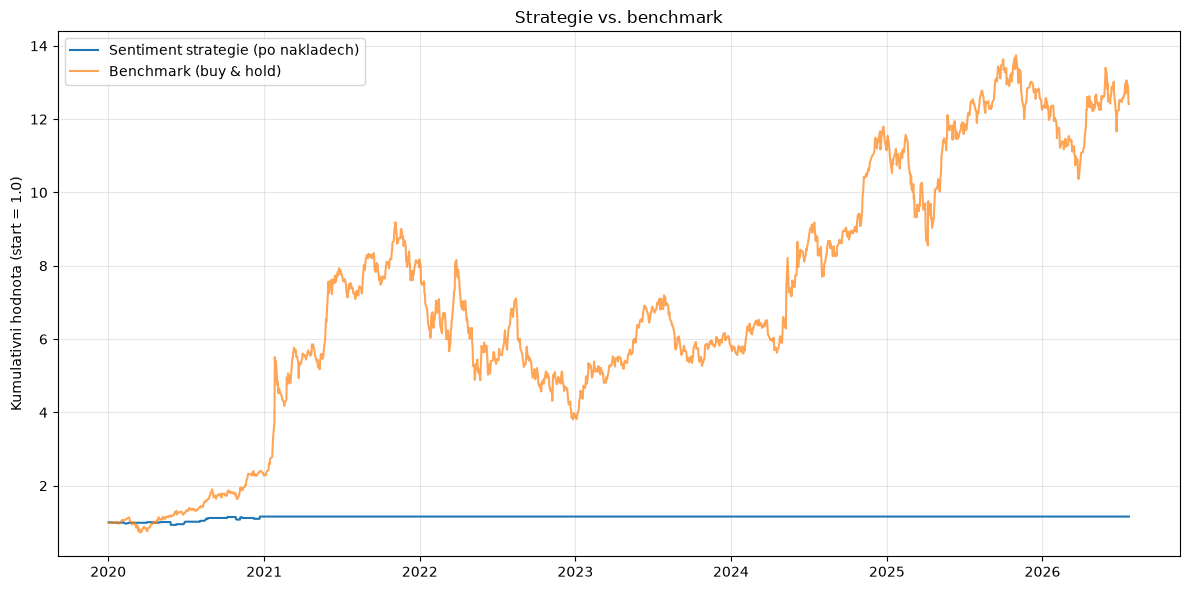

In [12]:
strategy_equity = (1 + strategy_returns_net).cumprod()
benchmark_equity = (1 + benchmark_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(strategy_equity.index, strategy_equity.values, label="Sentiment strategie (po nakladech)", linewidth=1.5)
ax.plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark (buy & hold)", linewidth=1.5, alpha=0.7)
ax.set_ylabel("Kumulativni hodnota (start = 1.0)")
ax.set_title("Strategie vs. benchmark")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Rizikove metriky

Kumulativni vynos sam o sobe nic nerika o riziku, ktere jsi cestou
podstoupil. Pocitame:

- **Sharpe ratio** -- vynos na jednotku volatility (vyssi = lepsi,
  nad 1.0 se povazuje za slusne, nad 2.0 za velmi dobre)
- **Max drawdown** -- nejvetsi propad od predchoziho maxima
- **Win rate** -- podil dni s kladnym vynosem

In [13]:
def compute_metrics(returns: pd.Series, label: str, active_only: pd.Series = None) -> dict:
    ann_return = (1 + returns).prod() ** (252 / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    equity = (1 + returns).cumprod()
    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    max_drawdown = drawdown.min()

    # Win rate pocitame jen mezi dny, kdy strategie skutecne obchodovala --
    # dny s nulovym vynosem (mimo trh) by jinak zkreslovaly cislo smerem
    # dolu, i kdyz nejde o "prohru", ale o zadny obchod
    if active_only is not None:
        active_returns = returns[active_only]
        win_rate = (active_returns > 0).mean() if len(active_returns) > 0 else np.nan
        win_rate_label = "Win rate (aktivni dny)"
    else:
        win_rate = (returns > 0).mean()
        win_rate_label = "Win rate"

    return {
        "label": label,
        "Celkovy vynos": f"{(equity.iloc[-1] - 1) * 100:.1f} %",
        "Anualizovany vynos": f"{ann_return * 100:.1f} %",
        "Anualizovana volatilita": f"{ann_vol * 100:.1f} %",
        "Sharpe ratio": f"{sharpe:.2f}",
        "Max drawdown": f"{max_drawdown * 100:.1f} %",
        win_rate_label: f"{win_rate * 100:.1f} %",
    }

metrics_strategy = compute_metrics(strategy_returns_net, "Sentiment strategie", active_only=trade_days.values)
metrics_benchmark = compute_metrics(benchmark_returns, "Benchmark (buy & hold)")

pd.DataFrame([metrics_strategy, metrics_benchmark]).set_index("label").T

label,Sentiment strategie,Benchmark (buy & hold)
Celkovy vynos,15.7 %,1141.1 %
Anualizovany vynos,2.3 %,47.0 %
Anualizovana volatilita,6.4 %,44.8 %
Sharpe ratio,0.35,1.05
Max drawdown,-7.8 %,-58.5 %
Win rate (aktivni dny),60.0 %,NaN
Win rate,NaN,53.1 %


**Poznamka k interpretaci:** Benchmark ma vyrazne vyssi absolutni vynos,
ale take vyrazne vyssi volatilitu a mnohem hlubsi max drawdown -- to je
z velke casti dusledkem toho, ze nas benchmark obsahuje GME/AMC/TSLA
prave behem jejich nejdivocejsiho obdobi (2020-2021), coz neni typicke
chovani portfolia. Strategie je naopak vyrazne konzervativnejsi (vetsinu
casu mimo trh), coz vysvetluje nizky drawdown, ale i nizky absolutni
vynos. Definitivni zaver o tom, jestli je to "dobra" strategie, pockame
az na permutacni test nize -- absolutni cisla sama o sobe bez kontextu
rizika a statisticke vyznamnosti nic neprokazuji.

## 9. Je to nahoda? Permutacni test

Strategie mohla "vyhrat" nad benchmarkem cistou nahodou. Otestujeme to
permutacnim testem: **nahodne zamichame, ve kterych dnech strategie
obchoduje** (zachovame stejny POCET obchodnich dni, jen jiny vyber), a
podivame se, jak casto by nahodne casovani dosahlo stejneho nebo
lepsiho vysledku.

In [14]:
N_PERMUTATIONS = 1000

actual_total_return = strategy_equity.iloc[-1] - 1
n_trade_days = int(trade_days.sum())

all_forward_returns_by_date = df.groupby("Date")["Forward_Return"].mean().reindex(all_dates).fillna(0.0).values

random_results = []
for _ in range(N_PERMUTATIONS):
    random_trade_idx = np.random.choice(len(all_dates), size=n_trade_days, replace=False)
    random_returns = np.zeros(len(all_dates))
    random_returns[random_trade_idx] = all_forward_returns_by_date[random_trade_idx] - TRANSACTION_COST
    random_total_return = np.prod(1 + random_returns) - 1
    random_results.append(random_total_return)

random_results = np.array(random_results)
p_value = (random_results >= actual_total_return).mean()

print(f"Skutecny vynos strategie:         {actual_total_return * 100:.1f} %")
print(f"Prumerny vynos nahodneho timingu: {random_results.mean() * 100:.1f} %")
print(f"P-hodnota (podil nahodnych pokusu >= skutecny vysledek): {p_value:.3f}")

Skutecny vynos strategie:         15.7 %
Prumerny vynos nahodneho timingu: 1.9 %
P-hodnota (podil nahodnych pokusu >= skutecny vysledek): 0.131


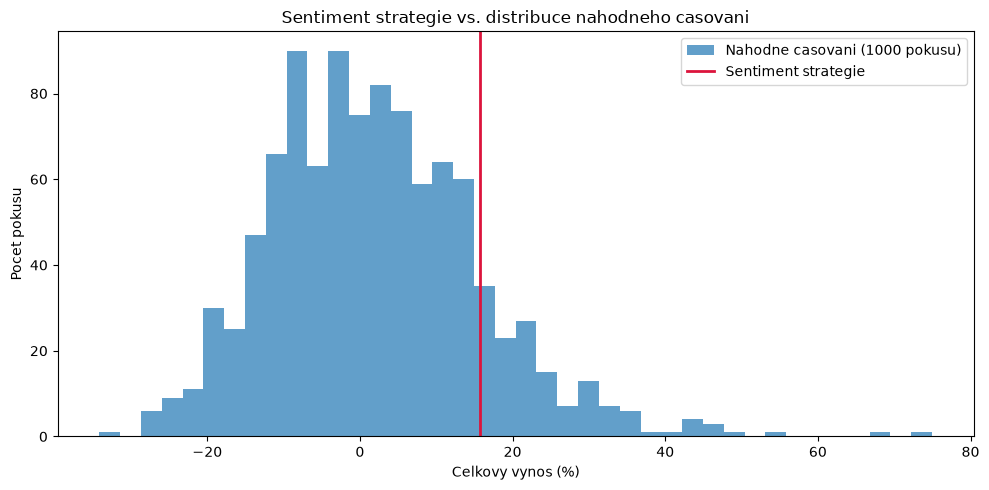

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(random_results * 100, bins=40, alpha=0.7, label="Nahodne casovani (1000 pokusu)")
ax.axvline(actual_total_return * 100, color="crimson", linewidth=2, label="Sentiment strategie")
ax.set_xlabel("Celkovy vynos (%)")
ax.set_ylabel("Pocet pokusu")
ax.set_title("Sentiment strategie vs. distribuce nahodneho casovani")
ax.legend()
plt.tight_layout()
plt.show()

**Jak cist p-hodnotu:** pokud je napriklad 0.05, znamena to, ze jen
5 % nahodnych strategii se stejnym poctem obchodu dosahlo stejneho nebo
lepsiho vysledku -- coz je slusny dukaz, ze sentiment signal skutecne
neco vypovida (ne jistota, ale rozumny dukaz proti ciste nahode).
Naopak p-hodnota kolem 0.5 by znamenala, ze strategie neni o nic lepsi
nez hazeni kostkou.

## 10. Out-of-sample test

Vsechno vyse jsme pocitali na celem obdobi najednou -- coz je riziko
overfittingu (parametry ZSCORE_THRESHOLD a VOLUME_THRESHOLD jsme volili
"od oka", ale kdybychom je ladili podle vysledku na celych datech,
bylo by to podvadeni). Rozdelime data chronologicky na trenovaci
(prvnich 70 %) a testovaci (poslednich 30 %) obdobi a podivame se,
jestli strategie funguje i na datech, ktera "nevidela".

In [16]:
split_idx = int(len(all_dates) * 0.7)
split_date = all_dates.iloc[split_idx]

print(f"Trenovaci obdobi: {all_dates.iloc[0].date()} az {split_date.date()}")
print(f"Testovaci obdobi: {split_date.date()} az {all_dates.iloc[-1].date()}")

in_sample_mask = all_dates <= split_date
out_sample_mask = ~in_sample_mask

is_returns = strategy_returns_net[in_sample_mask.values]
oos_returns = strategy_returns_net[out_sample_mask.values]
is_benchmark = benchmark_returns[in_sample_mask.values]
oos_benchmark = benchmark_returns[out_sample_mask.values]

is_trade_days = trade_days.values & in_sample_mask.values
oos_trade_days = trade_days.values & out_sample_mask.values

comparison = pd.DataFrame([
    compute_metrics(is_returns, "Strategie (in-sample)", active_only=is_trade_days[in_sample_mask.values]),
    compute_metrics(oos_returns, "Strategie (out-of-sample)", active_only=oos_trade_days[out_sample_mask.values]),
    compute_metrics(is_benchmark, "Benchmark (in-sample)"),
    compute_metrics(oos_benchmark, "Benchmark (out-of-sample)"),
]).set_index("label").T

comparison

Trenovaci obdobi: 2020-01-02 az 2024-08-01
Testovaci obdobi: 2024-08-01 az 2026-07-23


label,Strategie (in-sample),Strategie (out-of-sample),Benchmark (in-sample),Benchmark (out-of-sample)
Celkovy vynos,15.7 %,0.0 %,696.1 %,55.9 %
Anualizovany vynos,3.2 %,0.0 %,57.4 %,25.4 %
Anualizovana volatilita,7.7 %,0.0 %,50.3 %,28.0 %
Sharpe ratio,0.42,nan,1.14,0.91
Max drawdown,-7.8 %,0.0 %,-58.5 %,-27.5 %
Win rate (aktivni dny),60.0 %,nan %,NaN,NaN
Win rate,NaN,NaN,51.8 %,56.3 %


## Shrnuti a limitace

**Co backtest ukazuje:** vysledky vyse (Sharpe ratio, permutacni test,
out-of-sample srovnani) -- dopln si sem vlastni interpretaci az uvidis
skutecna cisla ze svych dat.

**Limitace, ktere je nutne priznat (a je to soucast poctive prace, ne
slabina):**

1. **Forward return aproximace** -- predpokladame obchod presne na
   Close dne T, realisticky by to bylo az Open T+1, coz by pridalo
   dalsi slippage.
2. **Zadny rozdil mezi long/short** -- strategie jen nakupuje, nikdy
   neshortuje, i kdyz negativni sentiment_zscore by teoreticky mohl byt
   signal k poklesu.
3. **Rovnomerne vahy** -- kazdy signal dostava stejnou vahu bez ohledu
   na silu z-score nad prahem.
4. **Jeden pevny parametr prahu** (1.5 / 1.0) nebyl systematicky laden
   (napr. grid search) -- volba "od oka" snizuje riziko preoptimalizace,
   ale zaroven znamena, ze jsme nenasli nutne nejlepsi mozne nastaveni.
5. **Sentiment model** (Twitter-RoBERTa) neni specificky doladeny na
   financni/trading slang -- jen obecne social-media sentiment.
6. **Prezity dataset (survivorship)** -- vsechny sledovane tickery
   existuji dodnes; historicky dataset by mel zahrnovat i firmy, ktere
   mezitim zkrachovaly nebo byly delistovany, aby byl vysledek plne
   nezkresleny.

**Dalsi kroky:** notebook 04 muze zahrnovat vizualizace pro finalni
prezentaci / README, a appka (Streamlit) pro interaktivni prohlizeni
vysledku.